- 주가 상승확률
- 조건부 상승확률
- 정보량
- 엔트로피
- 정규분포와 Z점수
- 크로스엔트로피

In [1]:
from pykrx import stock
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.metrics import log_loss

C:\Users\JYB\AppData\Local\Programs\Python\Python39\lib\site-packages\pykrx\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### 1.삼성전자 실제 주가 가져오기

In [2]:
df = stock.get_market_ohlcv(
    fromdate="20250101",
    todate="20260731",
    ticker="005930"
)

if df.empty:
    raise ValueError("주가 데이터를 불러오지 못했습니다.")

print(df.head())

               시가     고가     저가     종가       거래량       등락률
날짜                                                        
2025-01-02  52700  53600  52300  53400  16630538  0.375940
2025-01-03  52800  55100  52800  54400  19318046  1.872659
2025-01-06  54400  56200  54300  55900  19034284  2.757353
2025-01-07  56800  57300  55400  55400  17030235 -0.894454
2025-01-08  54800  57500  54700  57300  26593553  3.429603


### 2.일간수익률과 상승 여부 계산

In [3]:
# 일간수익률(%)
df["수익률"] = df["종가"].pct_change() * 100

# 상승이면 1, 하락 또는 보합이면 0
df["상승여부"] = (df["수익률"] > 0).astype(int)

# 첫 번째 행의 결측값 제거
df = df.dropna()

print(df[["종가", "수익률", "상승여부"]].head())

               종가       수익률  상승여부
날짜                               
2025-01-03  54400  1.872659     1
2025-01-06  55900  2.757353     1
2025-01-07  55400 -0.894454     0
2025-01-08  57300  3.429603     1
2025-01-09  56100 -2.094241     0


In [4]:
# 결과 해석
# 상승여부 = 1: 전일보다 주가 상승
# 상승여부 = 0: 전일보다 하락 또는 보합

### 3.주가 상승확률 계산

In [ ]:
# 전체 거래일 중 주가가 상승한 날의 비율을 계산합니다.
# P(상승)=상승일수/전체 거래일수

In [5]:
up_days = df["상승여부"].sum()
total_days = len(df)

up_probability = up_days / total_days

print("전체 거래일 수 :", total_days)
print("상승일 수      :", up_days)
print("상승확률       :", round(up_probability, 4))
print("상승확률       :", round(up_probability * 100, 2), "%")

전체 거래일 수 : 383
상승일 수      : 209
상승확률       : 0.5457
상승확률       : 54.57 %


In [ ]:
# 분석기간 중 약 54.57%의 거래일에서 삼성전자 주가가 상승했습니다.
# 이는 미래 상승확률을 확정적으로 예측한 값이 아니라, 분석기간에 관측된 경험적 확률입니다.

### 4. 조건부확률 계산

In [ ]:
# 전일 주가가 하락한 다음 날의 상승확률을 계산합니다.
# P(오늘 상승∣전일 하락)

In [6]:
# 전일 상승 여부
df["전일상승여부"] = df["상승여부"].shift(1)

# 전일 하락 또는 보합인 날만 선택
previous_down = df[df["전일상승여부"] == 0].copy()

conditional_probability = previous_down["상승여부"].mean()

print(
    "전일 하락 후 다음 날 상승확률 :",
    round(conditional_probability * 100, 2),
    "%"
)

전일 하락 후 다음 날 상승확률 : 55.17 %


In [7]:
print("전체 상승확률             :", round(up_probability * 100, 2), "%")
print(
    "전일 하락 후 상승확률     :",
    round(conditional_probability * 100, 2),
    "%"
)

전체 상승확률             : 54.57 %
전일 하락 후 상승확률     : 55.17 %


In [8]:
# 해석
# 전체 상승확률과 조건부 상승확률이 비슷하면 전일 하락 여부의 영향이 크지 않을 수 있습니다.
# 두 확률이 크게 다르면 전일 주가 방향이 다음 날 상승확률과 관련될 가능성이 있습니다.
# 다만 이것만으로 인과관계를 판단할 수는 없습니다.

### 5.정보량 계산

In [ ]:
# 특정 사건의 정보량은 다음과 같습니다.
# I(x)=−log2P(x)
# 발생확률이 낮은 사건일수록 정보량이 큽니다.

In [10]:
up_information = -np.log2(up_probability)
down_probability = 1 - up_probability
down_information = -np.log2(down_probability)

print("상승확률 :", round(up_probability, 4))
print("상승 정보량 :", round(up_information, 4), "bits")

print("비상승확률 :", round(down_probability, 4))
print("비상승 정보량 :", round(down_information, 4), "bits")

상승확률 : 0.5457
상승 정보량 : 0.8738 bits
비상승확률 : 0.4543
비상승 정보량 : 1.1383 bits


- 금융 부실 사례

In [ ]:
#부실확률이 5%라면 다음과 같습니다.

In [11]:
default_probability = 0.05

default_information = -np.log2(default_probability)

print("부실확률 :", default_probability)
print("부실 정보량 :", round(default_information, 4), "bits")

부실확률 : 0.05
부실 정보량 : 4.3219 bits


In [ ]:
#부실은 발생확률이 낮은 사건이므로 실제로 발생했을 때 정보량이 큽니다.

### 6. 엔트로피 계산

In [ ]:
# 주가 상승과 비상승이라는 두 결과의 전체 불확실성을 계산합니다.
# H(X)=−[plog2p+(1−p)log2(1−p)]
# p = up_probability


In [12]:
p = up_probability

entropy = -(
    p * np.log2(p)
    + (1 - p) * np.log2(1 - p)
)

print("상승확률 :", round(p, 4))
print("엔트로피 :", round(entropy, 4), "bits")

상승확률 : 0.5457
엔트로피 : 0.994 bits


- 확률에 따른 엔트로피 비교

In [13]:
probabilities = [0.01, 0.10, 0.30, 0.50, 0.70, 0.90, 0.99]

entropy_values = []

for p in probabilities:
    h = -(
        p * np.log2(p)
        + (1 - p) * np.log2(1 - p)
    )
    entropy_values.append(h)

entropy_df = pd.DataFrame({
    "상승확률": probabilities,
    "엔트로피": entropy_values
})

print(entropy_df)

   상승확률      엔트로피
0  0.01  0.080793
1  0.10  0.468996
2  0.30  0.881291
3  0.50  1.000000
4  0.70  0.881291
5  0.90  0.468996
6  0.99  0.080793


- 그래프

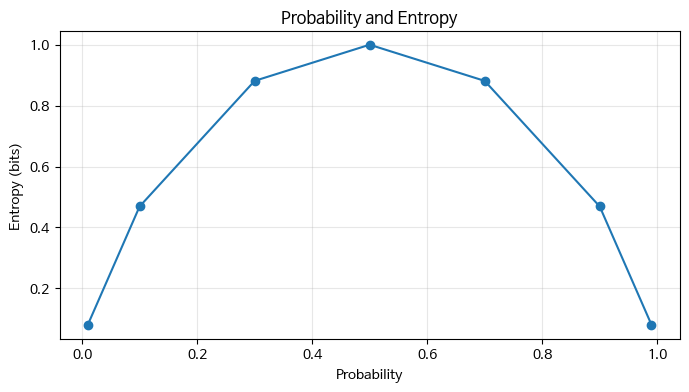

In [14]:
plt.figure(figsize=(8, 4))

plt.plot(
    entropy_df["상승확률"],
    entropy_df["엔트로피"],
    marker="o"
)

plt.title("Probability and Entropy")
plt.xlabel("Probability")
plt.ylabel("Entropy (bits)")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# 해석
# 상승확률이 50%에 가까우면 결과가 가장 불확실합니다.
# 상승확률이 0% 또는 100%에 가까우면 결과를 쉽게 예상할 수 있습니다.
# 이진 사건의 엔트로피는 p=0.5일 때 가장 큽니다.

### 7.수익률 분포와 정규분포 비교

#삼성전자 일간수익률의 히스토그램과 정규분포 곡선을 함께 그립니다

#SciPy의 norm.pdf()는 평균을 loc, 표준편차를 scale로 지정해 정규분포의 확률밀도함수를 계산합니다.

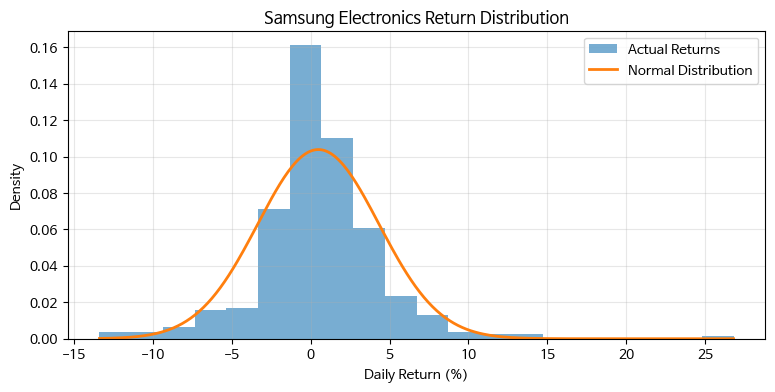

In [15]:
returns = df["수익률"]

mean_return = returns.mean()
std_return = returns.std()

x = np.linspace(
    returns.min(),
    returns.max(),
    300
)

normal_density = norm.pdf(
    x,
    loc=mean_return,
    scale=std_return
)

plt.figure(figsize=(9, 4))

plt.hist(
    returns,
    bins=20,
    density=True,
    alpha=0.6,
    label="Actual Returns"
)

plt.plot(
    x,
    normal_density,
    linewidth=2,
    label="Normal Distribution"
)

plt.title("Samsung Electronics Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# 해석
# 히스토그램: 실제 삼성전자 수익률 분포
# 곡선: 같은 평균과 표준편차를 갖는 정규분포
# 두 모양이 다르면 실제 수익률이 정규분포와 완전히 일치하지 않는다는 의미입니다.

### 8. Z점수로 급등·급락일 찾기

In [16]:
df["Z점수"] = (
    df["수익률"] - df["수익률"].mean()
) / df["수익률"].std()

extreme_days = df[
    df["Z점수"].abs() >= 2
]

print("Z점수 절댓값이 2 이상인 거래일")
print(
    extreme_days[
        ["종가", "수익률", "Z점수"]
    ]
)

Z점수 절댓값이 2 이상인 거래일
                종가        수익률       Z점수
날짜                                     
2026-02-03  167500  11.369681  2.833206
2026-03-03  195100  -9.884527 -2.701137
2026-03-04  172200 -11.737570 -3.183647
2026-03-05  191600  11.265970  2.806201
2026-03-09  173500  -7.810840 -2.161173
2026-03-10  187900   8.299712  2.033822
2026-04-01  189600  13.397129  3.361129
2026-05-06  266000  14.408602  3.624505
2026-05-15  270500  -8.614865 -2.370532
2026-05-21  299500   8.514493  2.089749
2026-06-01  349000  10.094637  2.501200
2026-06-08  295500 -10.182371 -2.778692
2026-06-09  322000   8.967851  2.207798
2026-06-23  310000 -12.305516 -3.331533
2026-06-24  340500   9.838710  2.434559
2026-07-02  286000  -9.062003 -2.486961
2026-07-03  309500   8.216783  2.012229
2026-07-13  254500 -10.701754 -2.913933
2026-07-16  255000  -8.765653 -2.409795
2026-07-24  249500  -7.592593 -2.104344
2026-07-28  220000 -13.385827 -3.612833
2026-07-31  262500  26.811594  6.854096


- 큰 변동일부터 확인합니다.

In [17]:
print(
    extreme_days[
        ["종가", "수익률", "Z점수"]
    ]
    .sort_values(
        "Z점수",
        key=lambda x: x.abs(),
        ascending=False
    )
    .head(10)
)

                종가        수익률       Z점수
날짜                                     
2026-07-31  262500  26.811594  6.854096
2026-05-06  266000  14.408602  3.624505
2026-07-28  220000 -13.385827 -3.612833
2026-04-01  189600  13.397129  3.361129
2026-06-23  310000 -12.305516 -3.331533
2026-03-04  172200 -11.737570 -3.183647
2026-07-13  254500 -10.701754 -2.913933
2026-02-03  167500  11.369681  2.833206
2026-03-05  191600  11.265970  2.806201
2026-06-08  295500 -10.182371 -2.778692


In [ ]:
# 해석
# Z≥2: 평균보다 매우 높은 수익률
# Z≤−2: 평균보다 매우 낮은 수익률
# 금융시장에서는 실적 발표나 시장 충격이 발생한 날짜일 수 있습니다.

### 9. 크로스엔트로피 계산

In [ ]:
# 실제 주가 상승 여부와 모델이 예측한 상승확률의 차이를 측정합니다.
# 이진 크로스엔트로피는 다음과 같습니다.
# L=−[ylog(p^)+(1−y)log(1−p^)]

In [ ]:
# 사례 1: 실제로 상승한 경우
# 실제값:y=1
# 모델 A는 상승확률을 90%로 예측하고, 모델 B는 20%로 예측했다고 가정합니다.

#Scikit-learn의 log_loss()는 로지스틱 손실 또는 크로스엔트로피 손실을 계산하며, 확률예측 모델 평가에 사용됩니다.

In [18]:
actual = np.array([1])

model_A_probability = np.array([0.90])
model_B_probability = np.array([0.20])

loss_A = log_loss(
    actual,
    model_A_probability,
    labels=[0, 1]
)

loss_B = log_loss(
    actual,
    model_B_probability,
    labels=[0, 1]
)

print("모델 A 크로스엔트로피 :", round(loss_A, 4))
print("모델 B 크로스엔트로피 :", round(loss_B, 4))

모델 A 크로스엔트로피 : 0.1054
모델 B 크로스엔트로피 : 1.6094


In [ ]:
# 해석
# 실제로 상승했고 모델 A도 상승확률을 90%로 예측 → 손실이 작음